Step 1 Mounting Drive

In [ ]:
# Mounting drive

from google.colab import drive
drive.mount('/content/drive')
!pip install mne

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2 Preprocessing

Loading epochs from: /content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif
Reading /content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif ...
    Read a total of 1 projection items:
        Average EEG reference (1 x 32) active
    Found the data of interest:
        t =       0.00 ...    2000.00 ms
        0 CTF compensation matrices available
Not setting metadata
98 matching events found
No baseline correction applied
Created an SSP operator (subspace dimension = 1)
1 projection items activated

--- Epochs Info ---
Number of epochs: 98
Data shape (epochs, channels, time points): (98, 32, 1025)
Sampling frequency: 512.0 Hz
Channel names: ['Fp1', 'AF3', 'F7', 'F3', 'FC1']... (first 5 of 32 channels)
Epoch duration: 0.0 to 2.0 seconds
Using matplotlib as 2D backend.


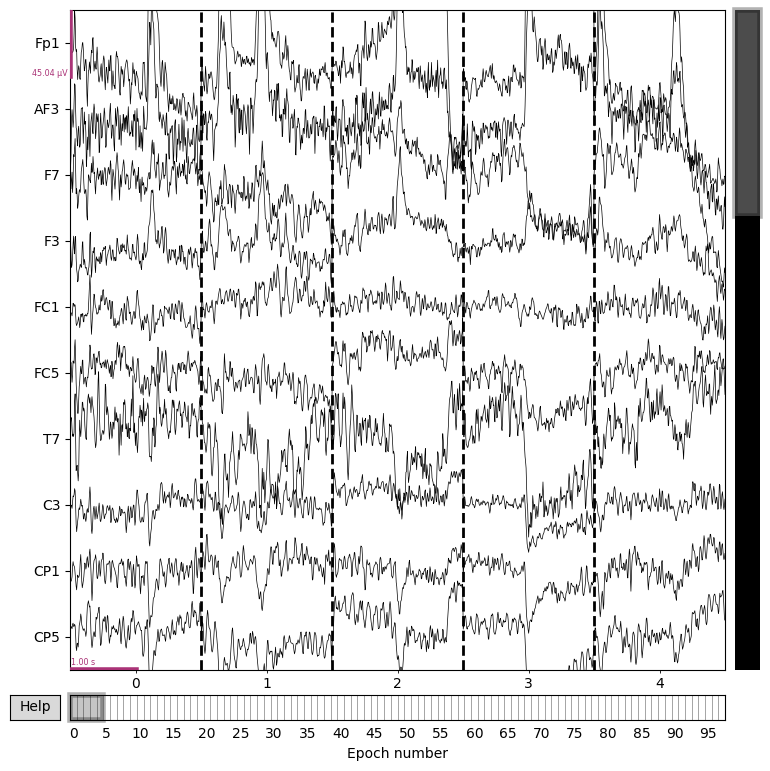

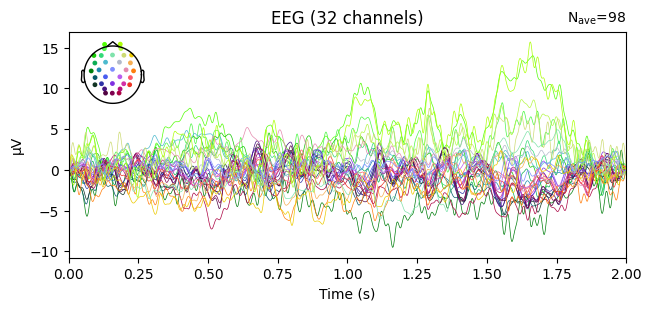

In [ ]:
# Verify preprocessed output
# After the preprocessing cell finishes execution, all your selected .bdf files will have been preprocessed and saved as .fif files in the Preprocessed_EEG_SanDiego folder in your Google Drive. You can use the following cell to load and inspect one of these .fif files to confirm the successful preprocessing.

import mne
import os
import matplotlib.pyplot as plt

# Replace this with the actual path to one of your saved .fif files
# You can choose one from the output of the previous cell, or from your Drive folder.
example_fif_path = '/content/drive/MyDrive/Preprocessed_EEG_SanDiego/sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif'

if os.path.exists(example_fif_path):
    print(f"Loading epochs from: {example_fif_path}")
    loaded_epochs = mne.read_epochs(example_fif_path, preload=True)
    print("\n--- Epochs Info ---")
    print(f"Number of epochs: {len(loaded_epochs)}")
    print(f"Data shape (epochs, channels, time points): {loaded_epochs.get_data().shape}")
    print(f"Sampling frequency: {loaded_epochs.info['sfreq']} Hz")
    print(f"Channel names: {loaded_epochs.ch_names[:5]}... (first 5 of {len(loaded_epochs.ch_names)} channels)")
    print(f"Epoch duration: {loaded_epochs.tmin} to {loaded_epochs.tmax} seconds")

    # Optional: Plot a few epochs to visually inspect
    loaded_epochs.plot(n_epochs=5, n_channels=10, scalings='auto', title='Sample Preprocessed Epochs')
    plt.show()

    # Optional: Plot evoked response (average of all epochs)
    evoked = loaded_epochs.average()
    evoked.plot(time_unit='s')
    plt.show()

else:
    print(f"Error: {example_fif_path} not found. Please verify the path and ensure the preprocessing has completed.")
    print("Make sure to replace `example_fif_path` with an actual path to a file in your `Preprocessed_EEG_SanDiego` folder.")

Step 3 Epoching, Subject-Wise Splitting and Normalization

In [ ]:
# Replacing Simulated Data with Real EEG Dataset

import mne
import os
import numpy as np

# Define the directory where your preprocessed .fif files are stored
REAL_EEG_DATA_DIR = '/content/drive/MyDrive/Preprocessed_EEG_SanDiego'

print(f"--- Loading Real EEG Data from: {REAL_EEG_DATA_DIR} ---")

# Check if the directory exists
if not os.path.exists(REAL_EEG_DATA_DIR):
    raise FileNotFoundError(f"The directory '{REAL_EEG_DATA_DIR}' does not exist. Please ensure your preprocessed .fif files are in this location.")

# Lists to store aggregated real data
X_real_list = []
y_real_list = []
subject_ids_real_list = []

# Iterate through all .fif files in the directory
fif_files = [f for f in os.listdir(REAL_EEG_DATA_DIR) if f.endswith('-epo.fif')]

if not fif_files:
    raise ValueError(f"No .fif epoch files found in '{REAL_EEG_DATA_DIR}'. Please check the directory and file naming convention.")

for i, filename in enumerate(sorted(fif_files)):
    filepath = os.path.join(REAL_EEG_DATA_DIR, filename)
    print(f"  Loading {i+1}/{len(fif_files)}: {filename}")

    try:
        epochs = mne.read_epochs(filepath, preload=True, verbose=False)

        # Extract data
        X_real_list.append(epochs.get_data())

        # Extract subject ID from filename (e.g., 'sub-pd5' from 'sub-pd5_ses-off_task-rest_eeg_preprocessed-epo.fif')
        subject_id = filename.split('_')[0]
        subject_ids_real_list.extend([subject_id] * len(epochs))

        # Infer label (0 for HC, 1 for PD) from subject ID
        label = 1 if 'pd' in subject_id.lower() else 0
        y_real_list.append(np.full(len(epochs), label))

    except Exception as e:
        print(f"    Error loading or processing {filename}: {e}")
        continue # Skip this file and continue with the next

# Concatenate all loaded data to create the full real dataset
# Overwrite the 'simulated' variables as requested to maintain pipeline consistency
X_full_simulated = np.concatenate(X_real_list, axis=0)
y_full_simulated = np.concatenate(y_real_list, axis=0)
subject_ids_full_simulated = np.array(subject_ids_real_list)

print("\n--- Real Data Loading Complete ---")
print(f"New X_full_simulated shape (epochs, channels, timepoints): {X_full_simulated.shape}")
print(f"New y_full_simulated shape (epochs,): {y_full_simulated.shape}")
print(f"New subject_ids_full_simulated shape: {subject_ids_full_simulated.shape}")

# --- Assertions for Real Data ---
# Check that the number of epochs matches across X, y, and subject_ids
assert X_full_simulated.shape[0] == y_full_simulated.shape[0], "Assertion Failed: Number of epochs in X_full_simulated and y_full_simulated do not match."
assert X_full_simulated.shape[0] == subject_ids_full_simulated.shape[0], "Assertion Failed: Number of epochs in X_full_simulated and subject_ids_full_simulated do not match."

# Check the number of unique subjects
unique_real_subjects = np.unique(subject_ids_full_simulated)
print(f"Unique real subjects loaded: {len(unique_real_subjects)}")
assert len(unique_real_subjects) > 0, "Assertion Failed: No unique subjects identified in the real dataset."

# Check that labels are binary (0 or 1)
assert np.all(np.isin(y_full_simulated, [0, 1])), "Assertion Failed: y_full_simulated contains labels other than 0 or 1."

# Check for NaN values in X_full_simulated
assert not np.isnan(X_full_simulated).any(), "Assertion Failed: NaN values found in X_full_simulated after loading real data."

print("Real data loading and initial assertions passed successfully. The simulated data variables have been replaced.")

--- Loading Real EEG Data from: /content/drive/MyDrive/Preprocessed_EEG_SanDiego ---
  Loading 1/31: sub-hc10_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 2/31: sub-hc18_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 3/31: sub-hc1_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 4/31: sub-hc20_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 5/31: sub-hc21_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 6/31: sub-hc24_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 7/31: sub-hc25_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 8/31: sub-hc29_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 9/31: sub-hc2_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 10/31: sub-hc30_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 11/31: sub-hc31_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 12/31: sub-hc32_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 13/31: sub-hc33_ses-hc_task-rest_eeg_preprocessed-epo.fif
  Loading 14/31: sub-hc4_ses-hc_task-rest_

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import gc # For explicit garbage collection

# --- 1. Verify Real Multi-Subject Data ---
# The X_full_simulated, y_full_simulated, and subject_ids_full_simulated variables
# are now expected to be populated with real data from the previous step.

print("--- Verifying Real EEG Data State ---")

# Assertions to confirm the real data loaded in the previous cell is now active
assert 'X_full_simulated' in locals(), "Assertion Failed: X_full_simulated not found. Real data was not loaded or assigned correctly."
assert 'y_full_simulated' in locals(), "Assertion Failed: y_full_simulated not found. Real data was not loaded or assigned correctly."
assert 'subject_ids_full_simulated' in locals(), "Assertion Failed: subject_ids_full_simulated not found. Real data was not loaded or assigned correctly."

# Check the shape of the loaded real data (epochs, channels, timepoints)
# Assuming n_channels=32 and n_timepoints=1025 from previous cells and original data structure
expected_channels = 32
expected_timepoints = 1025

assert X_full_simulated.shape[1] == expected_channels, f"Assertion Failed: X_full_simulated has {X_full_simulated.shape[1]} channels, but expected {expected_channels}."
assert X_full_simulated.shape[2] == expected_timepoints, f"Assertion Failed: X_full_simulated has {X_full_simulated.shape[2]} timepoints, but expected {expected_timepoints}."

# Verify the number of unique subjects (from previous step's print output, 31 unique real subjects)
actual_unique_subjects = len(np.unique(subject_ids_full_simulated))
expected_unique_subjects = 31 # Based on the output of the previous cell
assert actual_unique_subjects == expected_unique_subjects, f"Assertion Failed: Expected {expected_unique_subjects} unique subjects, but found {actual_unique_subjects}."

print(f"Verified X_full_simulated shape: {X_full_simulated.shape}")
print(f"Verified y_full_simulated shape: {y_full_simulated.shape}")
print(f"Verified unique subjects: {actual_unique_subjects}")
print("Real EEG data successfully verified and ready for cross-validation.")


# --- 2. Prepare for StratifiedGroupKFold Splitting ---

n_splits = 5
r_state = 42 # Renamed from random_state to avoid clash if used locally later

# Create a mapping from unique subject ID to its class label for stratification
unique_subjects = np.unique(subject_ids_full_simulated)
# Determine the class for each unique subject based on their ID (PD=1, HC=0)
y_subject_labels = np.array([1 if 'pd' in sub_id.lower() else 0 for sub_id in unique_subjects])

# Initialize StratifiedGroupKFold
sgk_fold = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=r_state) # Renamed sgkf

# List to store summary results (evaluation metrics, etc.) for each fold
all_fold_summary_results = []

print(f"\nStarting {n_splits}-fold subject-wise StratifiedGroupKFold cross-validation (memory-efficient mode)...")

# Iterate through each fold
# sgk_fold.split returns indices to `unique_subjects`
for fold_num, (train_sub_indices, test_sub_indices) in enumerate(sgk_fold.split(X=unique_subjects, y=y_subject_labels, groups=unique_subjects)):
    print(f"--- Processing Fold {fold_num + 1}/{n_splits} ---")

    # Get actual subject IDs for the current train/test split
    train_subjects_fold = unique_subjects[train_sub_indices]
    test_subjects_fold = unique_subjects[test_sub_indices]

    # Create masks to select epochs belonging to the current train/test subjects
    train_epoch_mask = np.isin(subject_ids_full_simulated, train_subjects_fold)
    test_epoch_mask = np.isin(subject_ids_full_simulated, test_subjects_fold)

    # --- Generate data for the current fold (memory-intensive step, but only for THIS fold) ---
    X_train_fold, y_train_fold = X_full_simulated[train_epoch_mask], y_full_simulated[train_epoch_mask]
    X_test_fold, y_test_fold = X_full_simulated[test_epoch_mask], y_full_simulated[test_epoch_mask]

    # Store original shapes for assertion after normalization
    X_train_fold_original_shape = X_train_fold.shape
    X_test_fold_original_shape = X_test_fold.shape

    # --- Normalization Step ---
    print("\n  Performing normalization...")
    epsilon = 1e-6 # Small value to prevent division by zero

    # Calculate mean and std for each channel independently across all epochs and timepoints in X_train
    # The mean/std will have shape (1, channels, 1) to broadcast correctly across epochs and timepoints
    train_mean = X_train_fold.mean(axis=(0, 2), keepdims=True)
    train_std = X_train_fold.std(axis=(0, 2), keepdims=True)

    # Handle potential zero standard deviation (e.g., if a channel is flatline)
    train_std_safe = np.where(train_std == 0, epsilon, train_std)

    # Print statistics before normalization (showing first 5 channels for brevity)
    print(f"  X_train mean before normalization (first 5 channels): {train_mean.flatten()[:5]}")
    print(f"  X_train std before normalization (first 5 channels): {train_std.flatten()[:5]}")

    # Apply normalization using training statistics
    X_train_fold_normalized = (X_train_fold - train_mean) / train_std_safe
    X_test_fold_normalized = (X_test_fold - train_mean) / train_std_safe

    # Print statistics after normalization (showing first 5 channels for brevity)
    print(f"  X_train mean after normalization (first 5 channels): {X_train_fold_normalized.mean(axis=(0, 2), keepdims=True).flatten()[:5]}")
    print(f"  X_train std after normalization (first 5 channels): {X_train_fold_normalized.std(axis=(0, 2), keepdims=True).flatten()[:5]}")
    print(f"  X_test mean after normalization (first 5 channels): {X_test_fold_normalized.mean(axis=(0, 2), keepdims=True).flatten()[:5]}")
    print(f"  X_test std after normalization (first 5 channels): {X_test_fold_normalized.std(axis=(0, 2), keepdims=True).flatten()[:5]}")

    # --- Assertions for Normalized Data ---
    assert not np.isnan(X_train_fold_normalized).any(), f"Assertion Failed: NaN values found in X_train_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isinf(X_train_fold_normalized).any(), f"Assertion Failed: Infinite values found in X_train_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isnan(X_test_fold_normalized).any(), f"Assertion Failed: NaN values found in X_test_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isinf(X_test_fold_normalized).any(), f"Assertion Failed: Infinite values found in X_test_fold_normalized after normalization in Fold {fold_num + 1}!"

    # Check shapes remain the same
    assert X_train_fold_normalized.shape == X_train_fold_original_shape, f"Assertion Failed: X_train_fold_normalized shape changed after normalization in Fold {fold_num + 1}!"
    assert X_test_fold_normalized.shape == X_test_fold_original_shape, f"Assertion Failed: X_test_fold_normalized shape changed after normalization in Fold {fold_num + 1}!"

    print("  Normalization and data integrity assertions passed.")

    # Reassign X_train_fold and X_test_fold to their normalized versions
    X_train_fold = X_train_fold_normalized
    X_test_fold = X_test_fold_normalized

    # Delete temporary variables related to normalization
    del train_mean, train_std, train_std_safe, X_train_fold_normalized, X_test_fold_normalized
    gc.collect()

    # --- Assertions to prevent data leakage (already existing) ---
    # 1. No subject appears in both training and testing
    assert len(set(train_subjects_fold).intersection(set(test_subjects_fold))) == 0, \
        f"Assertion Failed: Subject overlap detected in Fold {fold_num + 1}!"
    # 2. Every epoch from the subjects assigned to this fold belongs to exactly one split (train or test)
    total_epochs_in_fold = len(X_train_fold) + len(X_test_fold)
    expected_epochs_for_fold_subjects = np.sum(np.isin(subject_ids_full_simulated, np.concatenate((train_subjects_fold, test_subjects_fold))))
    assert total_epochs_in_fold == expected_epochs_for_fold_subjects, \
        f"Assertion Failed: Epoch count mismatch in Fold {fold_num + 1}! Expected {expected_epochs_for_fold_subjects}, got {total_epochs_in_fold}"

    print("  Data leakage assertions passed for this fold.")

    # Count PD/HC subjects and epochs in train and test sets (already existing)
    train_subject_classes = np.array([1 if 'pd' in s.lower() else 0 for s in train_subjects_fold])
    test_subject_classes = np.array([1 if 'pd' in s.lower() else 0 for s in test_subjects_fold])

    num_pd_train_subjects = np.sum(train_subject_classes == 1)
    num_hc_train_subjects = np.sum(train_subject_classes == 0)
    num_pd_test_subjects = np.sum(test_subject_classes == 1)
    num_hc_test_subjects = np.sum(test_subject_classes == 0)

    # Print information for the current fold (already existing)
    print(f"  Training Subject IDs ({len(train_subjects_fold)} subjects): {train_subjects_fold.tolist()}")
    print(f"  Testing Subject IDs ({len(test_subjects_fold)} subjects): {test_subjects_fold.tolist()}")
    print(f"  Number of training epochs: {len(X_train_fold)}")
    print(f"  Number of testing epochs: {len(X_test_fold)}")
    print(f"  PD subjects in training: {num_pd_train_subjects}, HC subjects in training: {num_hc_train_subjects}")
    print(f"  PD subjects in testing: {num_pd_test_subjects}, HC subjects in testing: {num_hc_test_subjects}")
    print(f"  PD epochs in training: {np.sum(y_train_fold == 1)}, HC epochs in training: {np.sum(y_train_fold == 0)}")
    print(f"  PD epochs in testing: {np.sum(y_test_fold == 1)}, HC epochs in testing: {np.sum(y_test_fold == 0)}")

    # --- Reshape data for EEGNet input ---
    print("\n  Reshaping data for EEGNet input...")
    print(f"  X_train_fold shape before reshape: {X_train_fold.shape}")
    print(f"  X_test_fold shape before reshape: {X_test_fold.shape}")

    # Reshape data for EEGNet input: (epochs, channels, timepoints, 1)
    X_train_fold_reshaped = X_train_fold[:, :, :, np.newaxis]
    X_test_fold_reshaped = X_test_fold[:, :, :, np.newaxis]

    print(f"  X_train_fold_reshaped shape after reshape: {X_train_fold_reshaped.shape}")
    print(f"  X_test_fold_reshaped shape after reshape: {X_test_fold_reshaped.shape}")

    # Assertions for reshaped data
    expected_train_shape = (*X_train_fold_original_shape, 1)
    expected_test_shape = (*X_test_fold_original_shape, 1)

    assert X_train_fold_reshaped.shape == expected_train_shape, \
        f"Assertion Failed: X_train_fold_reshaped has incorrect shape! Expected {expected_train_shape}, got {X_train_fold_reshaped.shape}"
    assert X_test_fold_reshaped.shape == expected_test_shape, \
        f"Assertion Failed: X_test_fold_reshaped has incorrect shape! Expected {expected_test_shape}, got {X_test_fold_reshaped.shape}"

    print("  Data reshaping and assertions passed.")

    # --- Placeholder for Model Training and Evaluation ---
    print("  (Placeholder: Here you would define, compile, train, and evaluate your EEGNet model...)")
    # Example: model.fit(X_train_fold, y_train_fold, ...)
    # Example: metrics = model.evaluate(X_test_fold, y_test_fold, ...)
    # Example: confusion_matrix_result = sklearn.metrics.confusion_matrix(y_test_fold, y_pred)

    # Store only the summary results for the current fold
    # Replace with actual metrics, confusion matrix, and training history once implemented.
    current_fold_results = {
        'fold_num': fold_num + 1,
        'metrics': {'accuracy': f'TBD_{fold_num+1}', 'precision': f'TBD_{fold_num+1}'},
        'confusion_matrix': f'TBD_matrix_{fold_num+1}',
        'training_history': f'TBD_history_{fold_num+1}'
    }
    all_fold_summary_results.append(current_fold_results)
    print(f"  Summary results for Fold {fold_num + 1} stored.\n")

    # --- Memory Management: Clean up large data variables after use ---
    del X_train_fold, y_train_fold, X_test_fold, y_test_fold
    del X_train_fold_reshaped, X_test_fold_reshaped # Delete reshaped data
    gc.collect() # Trigger garbage collection
    # If using TensorFlow/Keras, also clear the backend session here:
    # import tensorflow as tf
    # tf.keras.backend.clear_session()

    print(f"  Memory cleaned for Fold {fold_num + 1}.\n")

print("Subject-wise StratifiedGroupKFold splitting and processing complete.")
print(f"Total folds processed: {len(all_fold_summary_results)}")
print("Summary results across all folds (e.g., metrics, confusion matrices, training histories) are stored in `all_fold_summary_results`.")

--- Verifying Real EEG Data State ---
Verified X_full_simulated shape: (3009, 32, 1025)
Verified y_full_simulated shape: (3009,)
Verified unique subjects: 31
Real EEG data successfully verified and ready for cross-validation.

Starting 5-fold subject-wise StratifiedGroupKFold cross-validation (memory-efficient mode)...
--- Processing Fold 1/5 ---

  Performing normalization...
  X_train mean before normalization (first 5 channels): [-3.85136721e-07 -1.47132513e-07 -7.17084611e-08 -2.52735796e-08
  3.23391436e-08]
  X_train std before normalization (first 5 channels): [3.56386982e-05 2.11479451e-05 1.95374193e-05 1.43313332e-05
 8.51447553e-06]
  X_train mean after normalization (first 5 channels): [-7.34059272e-19  8.99814591e-19  1.35445775e-17  6.25134348e-18
 -1.90855411e-17]
  X_train std after normalization (first 5 channels): [1. 1. 1. 1. 1.]
  X_test mean after normalization (first 5 channels): [ 0.03136697  0.05047548  0.06615104 -0.02225596 -0.00563843]
  X_test std after norm

/tmp/ipykernel_1933/86679411.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


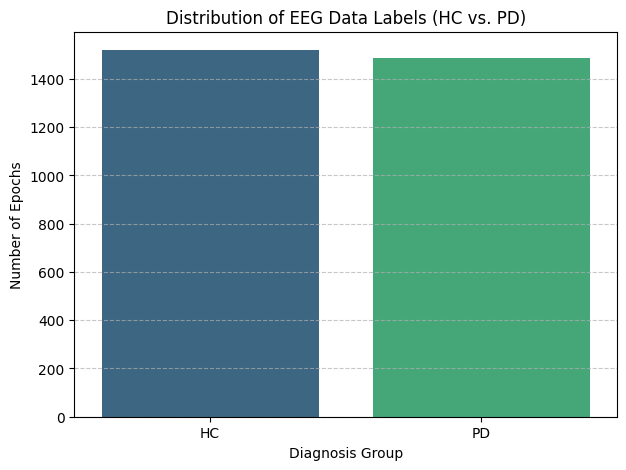

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count the occurrences of each class
class_counts = pd.Series(y_full_simulated).value_counts().sort_index()

# Map numerical labels to meaningful strings for the plot
class_labels = {0: 'HC', 1: 'PD'}
class_counts.index = class_counts.index.map(class_labels)

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Distribution of EEG Data Labels (HC vs. PD)')
plt.xlabel('Diagnosis Group')
plt.ylabel('Number of Epochs')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Step 4 Defining EEGNet

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

# --- EEGNet Model Definition ---
def EEGNet(n_channels, n_timepoints, n_classes, dropoutRate=0.5, kernLength=64, F1=8, D=2, F2=16):
    ''' Keras Implementation of EEGNet (Lawhern et al., 2018)
    Adapted for specific n_channels, n_timepoints, and n_classes.
    '''

    input_layer = layers.Input(shape=(n_channels, n_timepoints, 1))

    # Layer 1: Temporal Convolution followed by Depthwise Spatial Convolution
    # Temporal Convolution: Applies F1 filters across the time dimension.
    block1 = layers.Conv2D(F1, (1, kernLength), padding='same',
                           data_format='channels_last', use_bias=False)(input_layer)
    block1 = layers.BatchNormalization()(block1)
    # Depthwise Spatial Convolution: Applies D multipliers for each temporal filter across channels.
    block1 = layers.DepthwiseConv2D((n_channels, 1), use_bias=False,
                                    data_format='channels_last', depth_multiplier=D)(block1)
    block1 = layers.BatchNormalization()(block1)
    block1 = layers.Activation('elu')(block1)
    block1 = layers.AveragePooling2D((1, 4), data_format='channels_last')(block1)
    block1 = layers.Dropout(dropoutRate)(block1)

    # Layer 2: Separable Convolution
    # SeparableConv2D: Combines a depthwise spatial convolution and a pointwise convolution,
    # which is efficient for learning spatial and temporal features separately.
    block2 = layers.SeparableConv2D(F2, (1, 16), padding='same',
                                    data_format='channels_last', use_bias=False)(block1)
    block2 = layers.BatchNormalization()(block2)
    block2 = layers.Activation('elu')(block2)
    block2 = layers.AveragePooling2D((1, 8), data_format='channels_last')(block2)
    block2 = layers.Dropout(dropoutRate)(block2)

    # Flatten and Dense for classification
    flatten = layers.Flatten(name='flatten')(block2)
    # Dense Layer: The final classification layer with L2 regularization to prevent overfitting.
    # Uses 'softmax' activation for multi-class probability output (binary in this case).
    dense = layers.Dense(n_classes, name='dense', kernel_regularizer=regularizers.l2(0.01))(flatten)
    softmax = layers.Activation('softmax', name='softmax')(dense)

    return models.Model(inputs=input_layer, outputs=softmax)

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy

print("--- Instantiating and Compiling EEGNet Model ---")

# Define parameters based on your data (already available in kernel state)
n_channels = 32
n_timepoints = 1025
n_classes = 2 # Binary classification

# Instantiate the model
eegnet_model = EEGNet(n_channels=n_channels, n_timepoints=n_timepoints, n_classes=n_classes)

# Print the model summary
print("\n--- EEGNet Model Summary ---")
eegnet_model.summary()

# Define the optimizer
optimizer = Adam(learning_rate=0.001)

# Define the loss function
loss_fn = sparse_categorical_crossentropy

# Define the metrics
metrics = [
    SparseCategoricalAccuracy(name='accuracy')
]

# Compile the model
eegnet_model.compile(optimizer=optimizer, loss=loss_fn, metrics=metrics, run_eagerly=True)

print("\nEEGNet model compiled successfully with Adam optimizer, sparse_categorical_crossentropy loss, and SparseCategoricalAccuracy metric (running eagerly).")


--- Instantiating and Compiling EEGNet Model ---

--- EEGNet Model Summary ---


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 1025, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 1025, 8)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 1025, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 1025, 16)    │           512 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 1025, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 1025, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 256, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 256, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 256, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 256, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 32, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 32, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         1,026 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 2)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,722 (10.63 KB)

 Trainable params: 2,642 (10.32 KB)

 Non-trainable params: 80 (320.00 B)


EEGNet model compiled successfully with Adam optimizer, sparse_categorical_crossentropy loss, and SparseCategoricalAccuracy metric (running eagerly).


Step 5 Model Compilation

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import sparse_categorical_crossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy # Re-introducing SparseCategoricalAccuracy

# --- Model Compilation ---

# Define the optimizer
optimizer = Adam(learning_rate=0.001)

# Define the loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

# Define the metrics (re-introducing SparseCategoricalAccuracy)
metrics = [
    SparseCategoricalAccuracy(name='accuracy')
]

# Compile the model
eegnet_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)

print("EEGNet model compiled successfully with Adam optimizer, sparse_categorical_crossentropy loss, and SparseCategoricalAccuracy metric (running eagerly).")

EEGNet model compiled successfully with Adam optimizer, sparse_categorical_crossentropy loss, and SparseCategoricalAccuracy metric (running eagerly).


Step 6 Training for a Single Fold

In [ ]:
# Training EEGNet Model for a Single Fold Verification

import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import gc # Added for memory management if needed within this cell

# Assuming n_channels and n_timepoints are defined in a previous cell
# (e.g., from the EEGNet model definition or data loading steps)
# If not, please define them here based on your data:
# n_channels = 32
# n_timepoints = 1025

print("--- Pre-training Check for Single Fold ---")

# --- Reconstruct data for the last fold ---
# This block is added to re-create X_train_fold_reshaped, y_train_fold, X_test_fold_reshaped, y_test_fold
# which were cleared by the previous cell's memory management.
# It relies on `X_full_simulated`, `y_full_simulated`, `subject_ids_full_simulated`,
# `train_subjects_fold`, and `test_subjects_fold` being available in the kernel state
# from the last iteration of the cross-validation loop.
print("\n  Reconstructing data for the last fold...")

# Ensure required global variables are available
if 'X_full_simulated' not in locals() or 'y_full_simulated' not in locals() or \
   'subject_ids_full_simulated' not in locals() or 'train_subjects_fold' not in locals() or \
   'test_subjects_fold' not in locals():
    raise ValueError("Required full simulated data or last fold's subject IDs are not found."
                     "Please ensure the cross-validation loop cell has been run.")

# Create masks to select epochs belonging to the current train/test subjects
train_epoch_mask = np.isin(subject_ids_full_simulated, train_subjects_fold)
test_epoch_mask = np.isin(subject_ids_full_simulated, test_subjects_fold)

# Generate data for the current fold
X_train_fold, y_train_fold = X_full_simulated[train_epoch_mask], y_full_simulated[train_epoch_mask]
X_test_fold, y_test_fold = X_full_simulated[test_epoch_mask], y_full_simulated[test_epoch_mask]

# Store original shapes for assertion after normalization (optional, but good practice)
X_train_fold_original_shape = X_train_fold.shape
X_test_fold_original_shape = X_test_fold.shape

# --- Normalization Step (re-applied for the reconstructed fold data) ---
print("  Re-performing normalization...")
epsilon = 1e-6 # Small value to prevent division by zero

# Calculate mean and std for each channel independently across all epochs and timepoints in X_train
train_mean = X_train_fold.mean(axis=(0, 2), keepdims=True)
train_std = X_train_fold.std(axis=(0, 2), keepdims=True)
train_std_safe = np.where(train_std == 0, epsilon, train_std)

X_train_fold_normalized = (X_train_fold - train_mean) / train_std_safe
X_test_fold_normalized = (X_test_fold - train_mean) / train_std_safe

X_train_fold = X_train_fold_normalized
X_test_fold = X_test_fold_normalized

# Clean up normalization temp variables
del train_mean, train_std, train_std_safe, X_train_fold_normalized, X_test_fold_normalized
gc.collect()

# --- Reshape data for EEGNet input (re-applied) ---
print("  Re-reshaping data for EEGNet input...")
X_train_fold_reshaped = X_train_fold[:, :, :, np.newaxis]
X_test_fold_reshaped = X_test_fold[:, :, :, np.newaxis]
print("  Data reconstruction complete.")


# --- Assertions before Model Training ---
print("\n  Performing assertions before training...")

# Assert input shapes
assert 'eegnet_model' in locals(), "Assertion Failed: 'eegnet_model' is not defined. Please ensure the EEGNet model definition and compilation cells have been run."
assert 'X_train_fold_reshaped' in locals() and 'y_train_fold' in locals(), "Assertion Failed: Training data (X_train_fold_reshaped, y_train_fold) not found. Please ensure the cross-validation loop has run at least once."
assert 'X_test_fold_reshaped' in locals() and 'y_test_fold' in locals(), "Assertion Failed: Validation data (X_test_fold_reshaped, y_test_fold) not found. Please ensure the cross-validation loop has run at least once."


# Check if n_channels and n_timepoints are defined. If not, try to infer them.
if 'n_channels' not in locals() or 'n_timepoints' not in locals():
    if X_train_fold_reshaped.shape[1] is not None and X_train_fold_reshaped.shape[2] is not None:
        n_channels = X_train_fold_reshaped.shape[1]
        n_timepoints = X_train_fold_reshaped.shape[2]
        print(f"  Inferred n_channels={n_channels} and n_timepoints={n_timepoints} from X_train_fold_reshaped.")
    else:
        raise ValueError("n_channels and n_timepoints are not defined and cannot be inferred from X_train_fold_reshaped. Please define them manually.")


# Assert shapes based on expected EEGNet input (epochs, channels, timepoints, 1)
assert X_train_fold_reshaped.shape[1:] == (n_channels, n_timepoints, 1), f"Assertion Failed: X_train_fold_reshaped has unexpected channel/time/depth shape! Expected {(n_channels, n_timepoints, 1)}, got {X_train_fold_reshaped.shape[1:]}"
assert y_train_fold.ndim == 1, f"Assertion Failed: y_train_fold is not 1D! Got {y_train_fold.ndim} dimensions."
assert X_test_fold_reshaped.shape[1:] == (n_channels, n_timepoints, 1), f"Assertion Failed: X_test_fold_reshaped has unexpected channel/time/depth shape! Expected {(n_channels, n_timepoints, 1)}, got {X_test_fold_reshaped.shape[1:]}"
assert y_test_fold.ndim == 1, f"Assertion Failed: y_test_fold is not 1D! Got {y_test_fold.ndim} dimensions."

# Assert for NaN or Inf values in training data and labels
assert not np.isnan(X_train_fold_reshaped).any(), "Assertion Failed: NaN values found in X_train_fold_reshaped!"
assert not np.isinf(X_train_fold_reshaped).any(), "Assertion Failed: Infinite values found in X_train_fold_reshaped!"
assert not np.isnan(y_train_fold).any(), "Assertion Failed: NaN values found in y_train_fold!"
assert not np.isinf(y_train_fold).any(), "Assertion Failed: Infinite values found in y_train_fold!"

# Assert for NaN or Inf values in validation data and labels
assert not np.isnan(X_test_fold_reshaped).any(), "Assertion Failed: NaN values found in X_test_fold_reshaped!"
assert not np.isinf(X_test_fold_reshaped).any(), "Assertion Failed: Infinite values found in X_test_fold_reshaped!"
assert not np.isnan(y_test_fold).any(), "Assertion Failed: NaN values found in y_test_fold!"
assert not np.isinf(y_test_fold).any(), "Assertion Failed: Infinite values found in y_test_fold!"

print("  Pre-training assertions passed. Data is clean and correctly shaped.")

# --- Model Training for this single fold ---
print("\n  Starting training for a single fold...")

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint_filepath_single_fold = '/tmp/eegnet_best_model_single_fold.keras' # Unique path for this test run
model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath_single_fold, monitor='val_loss', save_best_only=True)

# Train the model
history = eegnet_model.fit(
    X_train_fold_reshaped,
    y_train_fold,
    epochs=50, # Train for up to 50 epochs as requested
    batch_size=32,
    validation_data=(X_test_fold_reshaped, y_test_fold),
    callbacks=[early_stopping, model_checkpoint],
    verbose=1 # Show training progress
)

# Print final training and validation loss and accuracy
print("\n--- Single Fold Training Results (last epoch) ---")
print(f"  Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Final Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

print(f"\nBest model for this single fold saved at: {checkpoint_filepath_single_fold}")
print("Single fold training complete.")

--- Pre-training Check for Single Fold ---

  Reconstructing data for the last fold...
  Re-performing normalization...
  Re-reshaping data for EEGNet input...
  Data reconstruction complete.

  Performing assertions before training...
  Pre-training assertions passed. Data is clean and correctly shaped.

  Starting training for a single fold...
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 111ms/step - accuracy: 0.5140 - loss: 0.8030 - val_accuracy: 0.4645 - val_loss: 0.7405
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5571 - loss: 0.7303 - val_accuracy: 0.4645 - val_loss: 0.7603
Epoch 3/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6333 - loss: 0.6749 - val_accuracy: 0.4661 - val_loss: 0.7731
Epoch 4/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6425 - loss: 0.6573 - val_accuracy: 0.4823 - val_loss: 0.7560
Epoch 5/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6559 - loss: 0.6366 - val_accuracy: 0.5355 - val_loss: 0.7400
Epoch 6/50
75/7

--- Evaluating the Best Model from Single Fold Training ---
Best model loaded from: /tmp/eegnet_best_model_single_fold.keras
Loaded model re-compiled.
Predictions generated successfully.

--- Evaluation Results ---
  Accuracy:  0.5355
  Precision: 0.6494
  Recall:    0.2994
  F1-Score:  0.4098
  ROC-AUC:   0.6893

  Confusion Matrix:
[[232  54]
 [234 100]]
Evaluation metrics and assertions passed successfully.


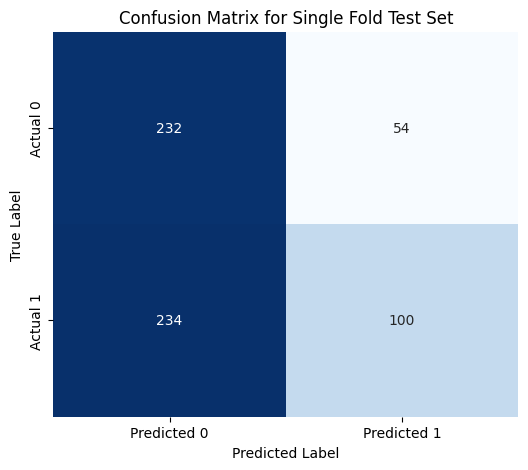

In [ ]:
# Evaluating the Best Model from Single Fold Training

import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Evaluating the Best Model from Single Fold Training ---")

# Assertions to ensure necessary variables are available
assert 'eegnet_model' in locals(), "Assertion Failed: 'eegnet_model' is not defined. Please ensure the EEGNet model definition and compilation cells have been run."
assert 'checkpoint_filepath_single_fold' in locals(), "Assertion Failed: 'checkpoint_filepath_single_fold' is not defined. Please ensure the single fold training cell has been run."
assert 'X_test_fold_reshaped' in locals() and 'y_test_fold' in locals(), "Assertion Failed: Test data (X_test_fold_reshaped, y_test_fold) not found. Please ensure data reconstruction was successful."

# Load the best model from the checkpoint
# We need to provide custom_objects if the model uses custom layers/functions
# In this case, EEGNet is a functional API model, so it should load directly if the EEGNet function is in scope.
# If EEGNet was a custom Keras Layer or Model subclass, we would need to pass it here.

best_model = tf.keras.models.load_model(checkpoint_filepath_single_fold, compile=False)
print(f"Best model loaded from: {checkpoint_filepath_single_fold}")

# Re-compile the loaded model. It's crucial to compile a loaded model if you want to resume training or evaluate.
# Use the same compilation parameters as defined previously.
# Ensure n_classes is defined globally or infer from y_test_fold unique values.
if 'n_classes' not in locals():
    n_classes = len(np.unique(y_test_fold))
    print(f"Inferred n_classes: {n_classes}")

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
)
print("Loaded model re-compiled.")

# Make predictions on the test set
y_pred_proba = best_model.predict(X_test_fold_reshaped, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Assertions on predictions
assert y_pred.shape == y_test_fold.shape, f"Assertion Failed: Predicted labels shape {y_pred.shape} does not match true labels shape {y_test_fold.shape}"
assert np.all(np.isin(y_pred, [0, 1])), "Assertion Failed: Predicted labels contain values other than 0 or 1."

print("Predictions generated successfully.")

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_fold, y_pred)
precision = precision_score(y_test_fold, y_pred, average='binary', zero_division=0)
recall = recall_score(y_test_fold, y_pred, average='binary', zero_division=0)
f1 = f1_score(y_test_fold, y_pred, average='binary', zero_division=0)

# ROC-AUC score for binary classification
# For ROC-AUC, we need the probability estimates of the positive class (class 1)
roc_auc = roc_auc_score(y_test_fold, y_pred_proba[:, 1])

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_fold, y_pred)

print("\n--- Evaluation Results ---")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print("\n  Confusion Matrix:")
print(conf_matrix)

# Assertions on calculated metrics
assert 0.0 <= accuracy <= 1.0, "Assertion Failed: Accuracy out of valid range."
assert 0.0 <= precision <= 1.0, "Assertion Failed: Precision out of valid range."
assert 0.0 <= recall <= 1.0, "Assertion Failed: Recall out of valid range."
assert 0.0 <= f1 <= 1.0, "Assertion Failed: F1-Score out of valid range."
assert 0.0 <= roc_auc <= 1.0, "Assertion Failed: ROC-AUC out of valid range."
assert isinstance(conf_matrix, np.ndarray) and conf_matrix.shape == (n_classes, n_classes), "Assertion Failed: Confusion matrix has incorrect type or shape."

print("Evaluation metrics and assertions passed successfully.")

# Optional: Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix for Single Fold Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Step 7 5-Fold Subject-Wise StratifiedGroupKFold Cross-Validation

--- Starting Full 5-Fold Cross-Validation for EEGNet ---

Starting 5-fold subject-wise StratifiedGroupKFold cross-validation (memory-efficient mode)...

--- Processing Fold 1/5 ---
  Training Subject IDs (24 subjects): ['sub-hc10', 'sub-hc18', 'sub-hc2', 'sub-hc20', 'sub-hc24', 'sub-hc25', 'sub-hc29', 'sub-hc30', 'sub-hc31', 'sub-hc33', 'sub-hc4', 'sub-hc7', 'sub-hc8', 'sub-pd12', 'sub-pd13', 'sub-pd14', 'sub-pd16', 'sub-pd17', 'sub-pd22', 'sub-pd23', 'sub-pd26', 'sub-pd3', 'sub-pd5', 'sub-pd6']
  Testing Subject IDs (7 subjects): ['sub-hc1', 'sub-hc21', 'sub-hc32', 'sub-pd11', 'sub-pd19', 'sub-pd28', 'sub-pd9']
  Number of training epochs: 2342
  Number of testing epochs: 667
  PD subjects in training: 11, HC subjects in training: 13
  PD subjects in testing: 4, HC subjects in testing: 3
  PD epochs in training: 1108, HC epochs in training: 1234
  PD epochs in testing: 381, HC epochs in testing: 286
  Performing normalization...
  Normalization and data integrity assertions passed.
  

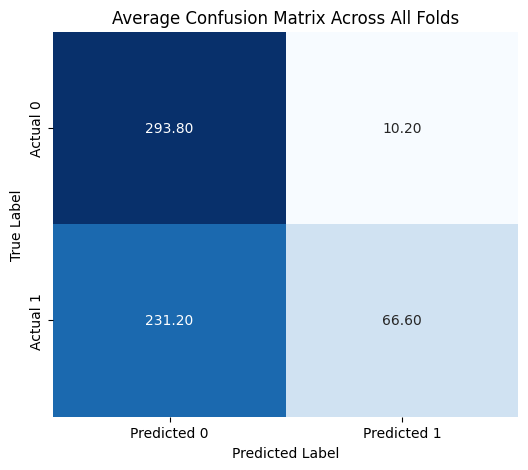


--- ROC Curves Across All Folds ---


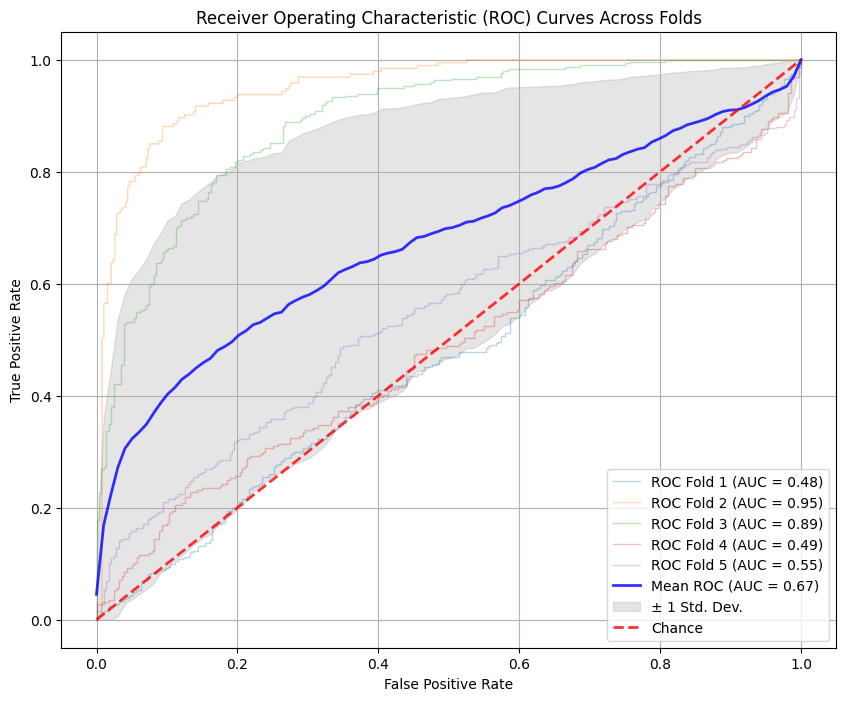

Detailed metrics for each fold are available in 'all_fold_accuracies', 'all_fold_precisions', etc.
Individual fold true labels and prediction probabilities are in 'all_fold_y_true' and 'all_fold_y_pred_proba_positive'.
Individual fold training histories are stored in 'all_fold_histories'.


In [ ]:
# 5-fold subject-wise StratifiedGroupKFold cross-validation

import numpy as np
import tensorflow as tf
from sklearn.model_selection import StratifiedGroupKFold
from collections import Counter
import gc # For explicit garbage collection
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from sklearn.utils import class_weight # Import for class weight calculation
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Starting Full 5-Fold Cross-Validation for EEGNet ---")

# Assertions to ensure necessary global variables are available
assert 'X_full_simulated' in locals(), "Assertion Failed: X_full_simulated not found. Real data was not loaded or assigned correctly."
assert 'y_full_simulated' in locals(), "Assertion Failed: y_full_simulated not found. Real data was not loaded or assigned correctly."
assert 'subject_ids_full_simulated' in locals(), "Assertion Failed: subject_ids_full_simulated not found. Real data was not loaded or assigned correctly."
assert 'EEGNet' in globals(), "Assertion Failed: EEGNet model definition function not found."
assert 'n_channels' in locals() and 'n_timepoints' in locals() and 'n_classes' in locals(), "Assertion Failed: EEGNet parameters (n_channels, n_timepoints, n_classes) not defined."

# --- 1. Prepare for StratifiedGroupKFold Splitting ---
n_splits = 5
r_state = 42 # Random state for reproducibility

# Create a mapping from unique subject ID to its class label for stratification
unique_subjects = np.unique(subject_ids_full_simulated)
y_subject_labels = np.array([1 if 'pd' in sub_id.lower() else 0 for sub_id in unique_subjects])

# Initialize StratifiedGroupKFold
sgk_fold = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=r_state)

# Lists to store metrics from each fold
all_fold_accuracies = []
all_fold_precisions = []
all_fold_recalls = []
all_fold_f1_scores = []
all_fold_roc_aucs = []
all_fold_confusion_matrices = []
all_fold_y_true = [] # To store true labels for ROC plotting
all_fold_y_pred_proba_positive = [] # To store prediction probabilities for positive class for ROC plotting
all_fold_histories = [] # NEW: To store training history for each fold

print(f"\nStarting {n_splits}-fold subject-wise StratifiedGroupKFold cross-validation (memory-efficient mode)...")

# Iterate through each fold
for fold_num, (train_sub_indices, test_sub_indices) in enumerate(sgk_fold.split(X=unique_subjects, y=y_subject_labels, groups=unique_subjects)):
    print(f"\n--- Processing Fold {fold_num + 1}/{n_splits} ---")

    # Get actual subject IDs for the current train/test split
    train_subjects_fold = unique_subjects[train_sub_indices]
    test_subjects_fold = unique_subjects[test_sub_indices]

    # Create masks to select epochs belonging to the current train/test subjects
    train_epoch_mask = np.isin(subject_ids_full_simulated, train_subjects_fold)
    test_epoch_mask = np.isin(subject_ids_full_simulated, test_subjects_fold)

    # --- Generate data for the current fold ---
    X_train_fold, y_train_fold = X_full_simulated[train_epoch_mask], y_full_simulated[train_epoch_mask]
    X_test_fold, y_test_fold = X_full_simulated[test_epoch_mask], y_full_simulated[test_epoch_mask]

    # Store original shapes for assertion after normalization
    X_train_fold_original_shape = X_train_fold.shape
    X_test_fold_original_shape = X_test_fold.shape

    # --- Print class distribution for the current fold (Added) ---
    train_subject_classes = np.array([1 if 'pd' in s.lower() else 0 for s in train_subjects_fold])
    test_subject_classes = np.array([1 if 'pd' in s.lower() else 0 for s in test_subjects_fold])

    num_pd_train_subjects = np.sum(train_subject_classes == 1)
    num_hc_train_subjects = np.sum(train_subject_classes == 0)
    num_pd_test_subjects = np.sum(test_subject_classes == 1)
    num_hc_test_subjects = np.sum(test_subject_classes == 0)

    print(f"  Training Subject IDs ({len(train_subjects_fold)} subjects): {train_subjects_fold.tolist()}")
    print(f"  Testing Subject IDs ({len(test_subjects_fold)} subjects): {test_subjects_fold.tolist()}")
    print(f"  Number of training epochs: {len(X_train_fold)}")
    print(f"  Number of testing epochs: {len(X_test_fold)}")
    print(f"  PD subjects in training: {num_pd_train_subjects}, HC subjects in training: {num_hc_train_subjects}")
    print(f"  PD subjects in testing: {num_pd_test_subjects}, HC subjects in testing: {num_hc_test_subjects}")
    print(f"  PD epochs in training: {np.sum(y_train_fold == 1)}, HC epochs in training: {np.sum(y_train_fold == 0)}")
    print(f"  PD epochs in testing: {np.sum(y_test_fold == 1)}, HC epochs in testing: {np.sum(y_test_fold == 0)}")

    # --- Normalization Step (replicated for each fold to prevent data leakage) ---
    print("  Performing normalization...")
    epsilon = 1e-6 # Small value to prevent division by zero

    # Calculate mean and std for each channel independently across all epochs and timepoints in X_train
    train_mean = X_train_fold.mean(axis=(0, 2), keepdims=True)
    train_std = X_train_fold.std(axis=(0, 2), keepdims=True)
    train_std_safe = np.where(train_std == 0, epsilon, train_std)

    # Apply normalization using training statistics
    X_train_fold_normalized = (X_train_fold - train_mean) / train_std_safe
    X_test_fold_normalized = (X_test_fold - train_mean) / train_std_safe

    # Assertions for Normalized Data
    assert not np.isnan(X_train_fold_normalized).any(), f"Assertion Failed: NaN values found in X_train_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isinf(X_train_fold_normalized).any(), f"Assertion Failed: Infinite values found in X_train_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isnan(X_test_fold_normalized).any(), f"Assertion Failed: NaN values found in X_test_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert not np.isinf(X_test_fold_normalized).any(), f"Assertion Failed: Infinite values found in X_test_fold_normalized after normalization in Fold {fold_num + 1}!"
    assert X_train_fold_normalized.shape == X_train_fold_original_shape, f"Assertion Failed: X_train_fold_normalized shape changed after normalization in Fold {fold_num + 1}!"
    assert X_test_fold_normalized.shape == X_test_fold_original_shape, f"Assertion Failed: X_test_fold_normalized shape changed after normalization in Fold {fold_num + 1}!"

    X_train_fold = X_train_fold_normalized
    X_test_fold = X_test_fold_normalized

    print("  Normalization and data integrity assertions passed.")

    # --- Reshape data for EEGNet input ---
    print("  Reshaping data for EEGNet input...")
    # Reshape data for EEGNet input: (epochs, channels, timepoints, 1)
    X_train_fold_reshaped = X_train_fold[:, :, :, np.newaxis]
    X_test_fold_reshaped = X_test_fold[:, :, :, np.newaxis]

    # Assertions for reshaped data
    expected_train_shape = (*X_train_fold_original_shape, 1)
    expected_test_shape = (*X_test_fold_original_shape, 1)
    assert X_train_fold_reshaped.shape == expected_train_shape, \
        f"Assertion Failed: X_train_fold_reshaped has incorrect shape! Expected {expected_train_shape}, got {X_train_fold_reshaped.shape}"
    assert X_test_fold_reshaped.shape == expected_test_shape, \
        f"Assertion Failed: X_test_fold_reshaped has incorrect shape! Expected {expected_test_shape}, got {X_test_fold_reshaped.shape}"
    print("  Data reshaping and assertions passed.")

    # --- Compute Class Weights (Added) ---
    print("  Computing class weights...")
    classes = np.unique(y_train_fold)
    weights = class_weight.compute_class_weight('balanced', classes=classes, y=y_train_fold)
    class_weights_dict = dict(zip(classes, weights))
    print(f"  Computed class weights for fold {fold_num + 1}: {class_weights_dict}")

    # --- Model Training and Evaluation ---
    print("  Instantiating, compiling, training, and evaluating EEGNet model for this fold...")

    # Clear previous model weights/session to ensure fresh training for each fold
    tf.keras.backend.clear_session()
    print("  TensorFlow Keras backend session cleared.")

    # Re-instantiate the EEGNet model for the current fold
    eegnet_model_fold = EEGNet(n_channels=n_channels, n_timepoints=n_timepoints, n_classes=n_classes)
    print("  EEGNet model re-instantiated.")

    # Compile the model with the same parameters
    optimizer_fold = Adam(learning_rate=0.001)
    loss_fn_fold = SparseCategoricalCrossentropy() # Keep this as original, label smoothing will be added in a later step
    metrics_fold = [SparseCategoricalAccuracy(name='accuracy')]
    eegnet_model_fold.compile(optimizer=optimizer_fold, loss=loss_fn_fold, metrics=metrics_fold, run_eagerly=True)
    print("  EEGNet model compiled for this fold.")

    # Assertions after model compilation
    assert len(eegnet_model_fold.weights) > 0, "Assertion Failed: Model has no weights after compilation!"
    assert eegnet_model_fold.optimizer is not None, "Assertion Failed: Model optimizer is None after compilation!"

    # Define callbacks for the current fold
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0) # Patience increased to 15
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0) # Added ReduceLROnPlateau
    # Use a temporary path for each fold's best model
    checkpoint_filepath_fold = f'/tmp/eegnet_best_model_fold_{fold_num + 1}.keras'
    model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath_fold, monitor='val_loss', save_best_only=True, verbose=0)

    # Train the model
    history = eegnet_model_fold.fit(
        X_train_fold_reshaped,
        y_train_fold,
        epochs=50, # Train for up to 50 epochs
        batch_size=32,
        validation_data=(X_test_fold_reshaped, y_test_fold),
        callbacks=[early_stopping, model_checkpoint, reduce_lr], # Added reduce_lr and updated early_stopping
        class_weight=class_weights_dict, # Pass computed class weights
        verbose=0 # Suppress verbose output for cleaner log
    )
    # NEW: Store the history for this fold
    all_fold_histories.append(history.history)
    print("  Model training complete.")

    # Assertions after model training
    assert 'loss' in history.history, "Assertion Failed: Training history does not contain 'loss'!"
    assert 'val_loss' in history.history, "Assertion Failed: Training history does not contain 'val_loss'!"
    assert len(history.history['loss']) > 0, "Assertion Failed: Training history is empty!"

    # Load the best model weights for evaluation
    eegnet_model_fold.load_weights(checkpoint_filepath_fold)
    print("  Best model weights loaded for evaluation.")

    # Evaluate the model on the test set for loss and accuracy
    loss_fold, accuracy_fold = eegnet_model_fold.evaluate(X_test_fold_reshaped, y_test_fold, verbose=0)
    print(f"  Evaluation results (from Keras): Loss={loss_fold:.4f}, Accuracy={accuracy_fold:.4f}")

    # Make predictions for other metrics
    y_pred_proba = eegnet_model_fold.predict(X_test_fold_reshaped, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Assertions on predictions
    assert y_pred.shape == y_test_fold.shape, f"Assertion Failed: Predicted labels shape {y_pred.shape} does not match true labels shape {y_test_fold.shape} in Fold {fold_num + 1}"
    assert np.all(np.isin(y_pred, [0, 1])), f"Assertion Failed: Predicted labels contain values other than 0 or 1 in Fold {fold_num + 1}."

    # Calculate additional metrics using sklearn
    precision_fold = precision_score(y_test_fold, y_pred, average='binary', zero_division=0)
    recall_fold = recall_score(y_test_fold, y_pred, average='binary', zero_division=0)
    f1_fold = f1_score(y_test_fold, y_pred, average='binary', zero_division=0)
    roc_auc_fold = roc_auc_score(y_test_fold, y_pred_proba[:, 1])
    conf_matrix_fold = confusion_matrix(y_test_fold, y_pred)

    # Assertions on calculated metrics
    assert isinstance(accuracy_fold, float) and 0.0 <= accuracy_fold <= 1.0, "Assertion Failed: Accuracy out of valid range."
    assert isinstance(precision_fold, float) and 0.0 <= precision_fold <= 1.0, "Assertion Failed: Precision out of valid range."
    assert isinstance(recall_fold, float) and 0.0 <= recall_fold <= 1.0, "Assertion Failed: Recall out of valid range."
    assert isinstance(f1_fold, float) and 0.0 <= f1_fold <= 1.0, "Assertion Failed: F1-Score out of valid range."
    assert isinstance(roc_auc_fold, float) and 0.0 <= roc_auc_fold <= 1.0, "Assertion Failed: ROC-AUC out of valid range."
    assert isinstance(conf_matrix_fold, np.ndarray) and conf_matrix_fold.shape == (n_classes, n_classes), "Assertion Failed: Confusion matrix has incorrect type or shape."

    print(f"  Accuracy: {accuracy_fold:.4f}, Precision: {precision_fold:.4f}, Recall: {recall_fold:.4f}, F1-Score: {f1_fold:.4f}, ROC-AUC: {roc_auc_fold:.4f}")
    print("  Confusion Matrix:\n", conf_matrix_fold)

    # Store metrics for overall summary
    all_fold_accuracies.append(accuracy_fold)
    all_fold_precisions.append(precision_fold)
    all_fold_recalls.append(recall_fold)
    all_fold_f1_scores.append(f1_fold)
    all_fold_roc_aucs.append(roc_auc_fold)
    all_fold_confusion_matrices.append(conf_matrix_fold) # Store as array, not list, for easier averaging
    all_fold_y_true.append(y_test_fold) # Store true labels
    all_fold_y_pred_proba_positive.append(y_pred_proba[:, 1]) # Store positive class probabilities

    print(f"  Metrics for Fold {fold_num + 1} stored.\n")

    # --- Memory Management: Clean up large data variables after use ---
    del X_train_fold, y_train_fold, X_test_fold, y_test_fold
    del X_train_fold_reshaped, X_test_fold_reshaped
    del eegnet_model_fold, optimizer_fold, loss_fn_fold, metrics_fold
    del train_mean, train_std, train_std_safe, early_stopping, model_checkpoint, reduce_lr, history, y_pred_proba, y_pred, conf_matrix_fold
    del class_weights_dict, classes, weights # Delete class weight related variables
    gc.collect() # Trigger garbage collection
    print(f"  Memory cleaned for Fold {fold_num + 1}.\n")

print("Subject-wise StratifiedGroupKFold cross-validation complete.")

# --- Calculate and Print Final Summary Across All Folds ---
print("\n--- Cross-Validation Summary Across All Folds ---")

# Calculate Mean \u00B1 Standard Deviation for each metric
mean_accuracy = np.mean(all_fold_accuracies)
std_accuracy = np.std(all_fold_accuracies)

mean_precision = np.mean(all_fold_precisions)
std_precision = np.std(all_fold_precisions)

mean_recall = np.mean(all_fold_recalls)
std_recall = np.std(all_fold_recalls)

mean_f1_score = np.mean(all_fold_f1_scores)
std_f1_score = np.std(all_fold_f1_scores)

mean_roc_auc = np.mean(all_fold_roc_aucs)
std_roc_auc = np.std(all_fold_roc_aucs)

# Print neat summary table
print("| Metric      | Mean \u00B1 Std (5-fold CV) |")
print("|-------------|--------------------------|")
print(f"| Accuracy    | {mean_accuracy:.4f} \u00B1 {std_accuracy:.4f}         |")
print(f"| Precision   | {mean_precision:.4f} \u00B1 {std_precision:.4f}         |")
print(f"| Recall      | {mean_recall:.4f} \u00B1 {std_recall:.4f}         |")
print(f"| F1-Score    | {mean_f1_score:.4f} \u00B1 {std_f1_score:.4f}         |")
print(f"| ROC-AUC     | {mean_roc_auc:.4f} \u00B1 {std_roc_auc:.4f}         |")
print("------------------------------------------")

print(f"Total folds processed: {n_splits}")

# --- Compute and Plot Average Confusion Matrix (Added) ---
print("\n--- Average Confusion Matrix Across All Folds ---")
avg_conf_matrix = np.mean(all_fold_confusion_matrices, axis=0)
print("Average Confusion Matrix:\n", avg_conf_matrix.round(2))

plt.figure(figsize=(6, 5))
sns.heatmap(avg_conf_matrix, annot=True, fmt='.2f', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Average Confusion Matrix Across All Folds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- Plot ROC Curves (Added) ---
print("\n--- ROC Curves Across All Folds ---")
plt.figure(figsize=(10, 8))
all_fpr = []
all_tpr = []
interp_tpr = []
base_fpr = np.linspace(0, 1, 100)

for i, (y_true_fold, y_pred_proba_positive_fold) in enumerate(zip(all_fold_y_true, all_fold_y_pred_proba_positive)):
    fpr, tpr, _ = roc_curve(y_true_fold, y_pred_proba_positive_fold)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')
    interp_tpr.append(np.interp(base_fpr, fpr, tpr))

# Plot mean ROC curve
mean_tpr = np.mean(interp_tpr, axis=0)
mean_auc = auc(base_fpr, mean_tpr)
plt.plot(base_fpr, mean_tpr, color='blue', label=f'Mean ROC (AUC = {mean_auc:.2f})',
         lw=2, alpha=0.8)

# Plot standard deviation shading
std_tpr = np.std(interp_tpr, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(base_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label='\u00B1 1 Std. Dev.')

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves Across Folds')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print("Detailed metrics for each fold are available in 'all_fold_accuracies', 'all_fold_precisions', etc.")
print("Individual fold true labels and prediction probabilities are in 'all_fold_y_true' and 'all_fold_y_pred_proba_positive'.")
print("Individual fold training histories are stored in 'all_fold_histories'.") # NEW print statement

Step 8 Result Generation and Interpretation

In [ ]:
# This section generates a detailed classification report for each cross-validation fold, including precision, recall, f1-score, and support for each class.

from sklearn.metrics import classification_report
import numpy as np

print("--- Classification Reports Per Fold ---")

for fold_num, (y_true_fold, y_pred_proba_positive_fold) in enumerate(zip(all_fold_y_true, all_fold_y_pred_proba_positive)):
    print(f"\n--- Fold {fold_num + 1} Classification Report ---")
    # Convert probabilities to binary predictions using a 0.5 threshold
    y_pred_fold = (y_pred_proba_positive_fold > 0.5).astype(int)

    # Generate and print the classification report
    report = classification_report(y_true_fold, y_pred_fold, target_names=['Class 0 (HC)', 'Class 1 (PD)'], zero_division=0)
    print(report)


--- Classification Reports Per Fold ---

--- Fold 1 Classification Report ---
              precision    recall  f1-score   support

Class 0 (HC)       0.43      0.94      0.59       286
Class 1 (PD)       0.54      0.06      0.10       381

    accuracy                           0.43       667
   macro avg       0.48      0.50      0.34       667
weighted avg       0.49      0.43      0.31       667


--- Fold 2 Classification Report ---
              precision    recall  f1-score   support

Class 0 (HC)       0.85      0.97      0.91       384
Class 1 (PD)       0.93      0.66      0.77       193

    accuracy                           0.87       577
   macro avg       0.89      0.82      0.84       577
weighted avg       0.88      0.87      0.86       577


--- Fold 3 Classification Report ---
              precision    recall  f1-score   support

Class 0 (HC)       0.69      0.92      0.79       284
Class 1 (PD)       0.89      0.60      0.71       297

    accuracy                

--- Plotting Training and Validation Curves Per Fold ---


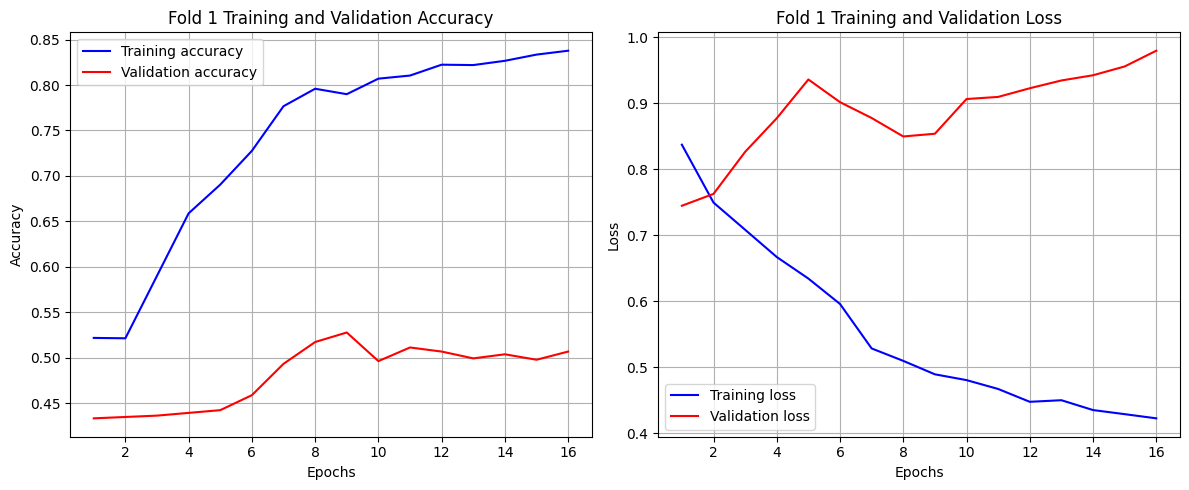

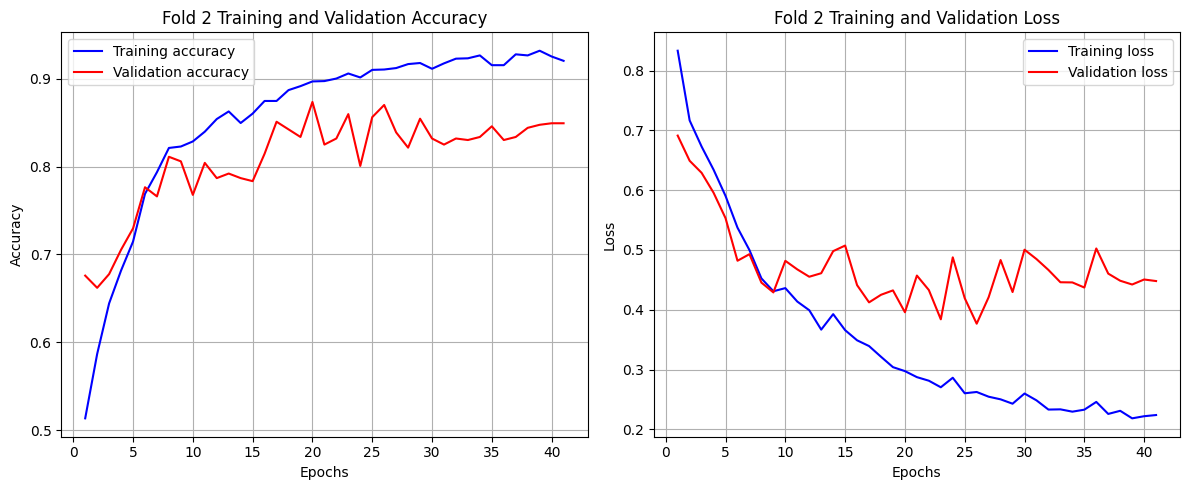

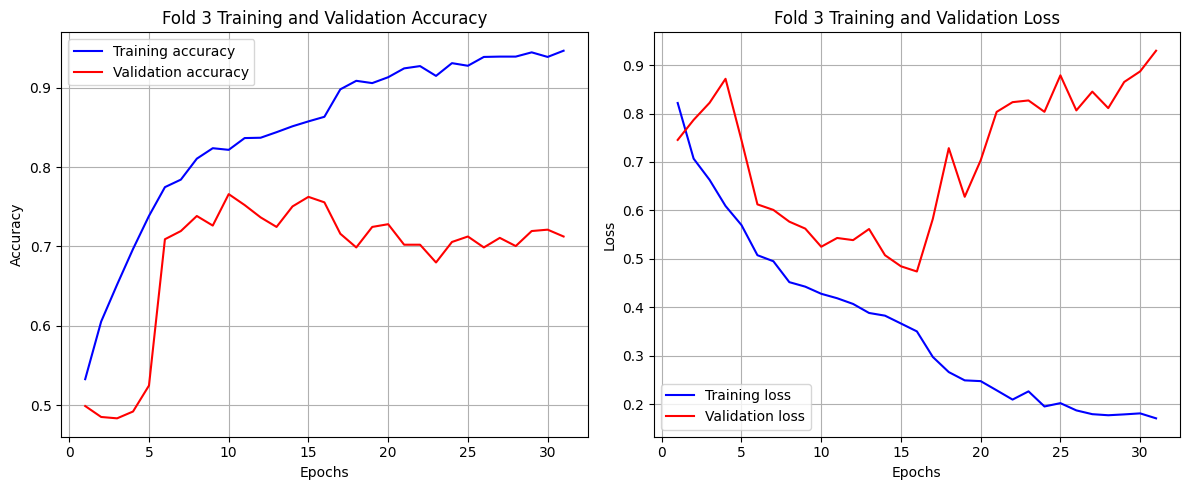

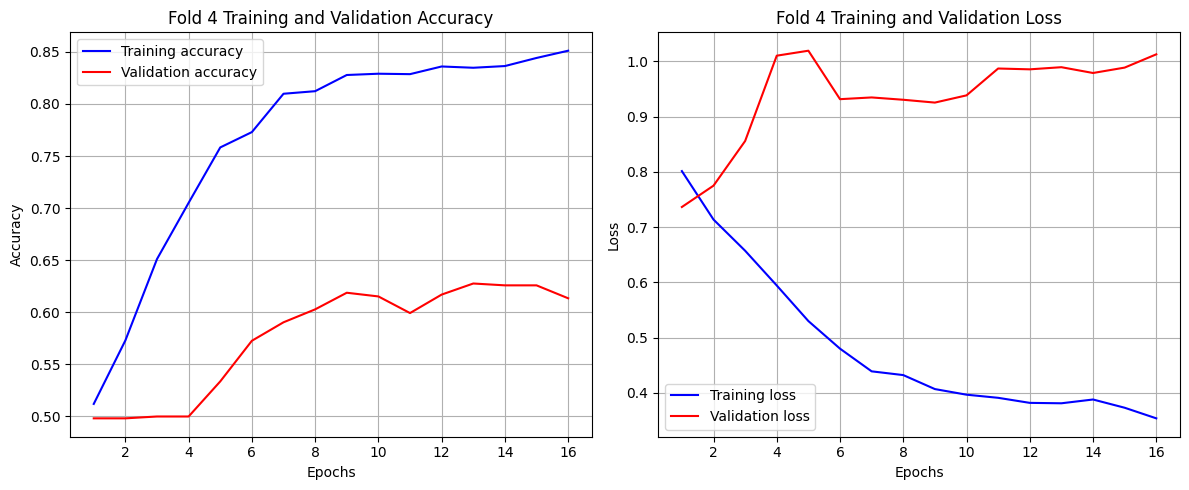

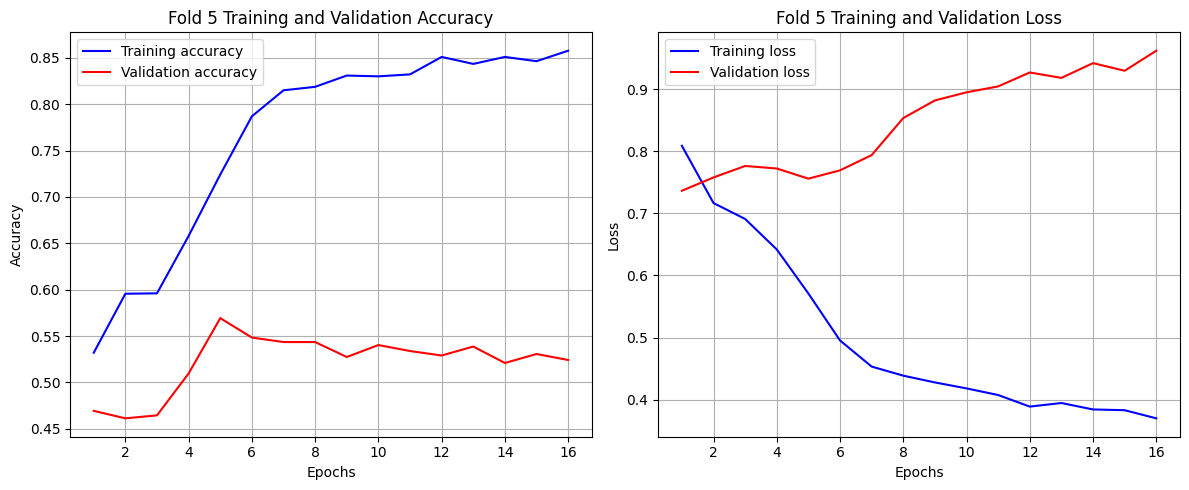

Training and Validation Curves plotting complete.


In [ ]:
# This section plots the training and validation accuracy and loss over epochs for each cross-validation fold.

import matplotlib.pyplot as plt

print("--- Plotting Training and Validation Curves Per Fold ---")

if not all_fold_histories:
    print("No training histories found. Please ensure the cross-validation cell (30a69241) was run successfully and `all_fold_histories` is populated.")
elif isinstance(all_fold_histories[0], dict):
    for fold_num, history_data in enumerate(all_fold_histories):
        epochs = range(1, len(history_data['accuracy']) + 1)

        plt.figure(figsize=(12, 5))

        # Plot Accuracy
        plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
        plt.plot(epochs, history_data['accuracy'], 'b', label='Training accuracy')
        plt.plot(epochs, history_data['val_accuracy'], 'r', label='Validation accuracy')
        plt.title(f'Fold {fold_num + 1} Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid(True)

        # Plot Loss
        plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
        plt.plot(epochs, history_data['loss'], 'b', label='Training loss')
        plt.plot(epochs, history_data['val_loss'], 'r', label='Validation loss')
        plt.title(f'Fold {fold_num + 1} Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)

        plt.tight_layout()
        plt.show()
else:
    print("Invalid format for `all_fold_histories`. Expected a list of dictionaries.")

print("Training and Validation Curves plotting complete.")


--- Confusion Matrices Per Fold ---


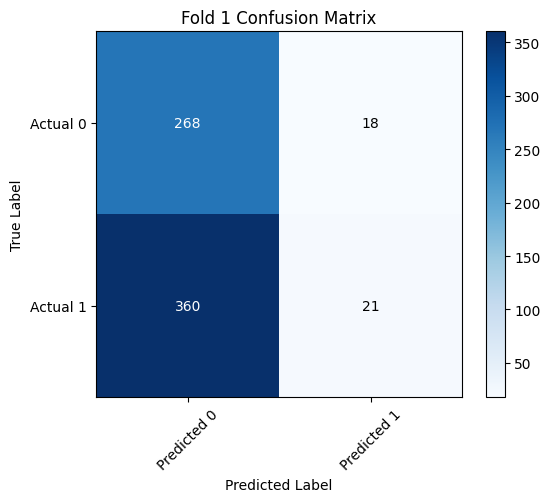

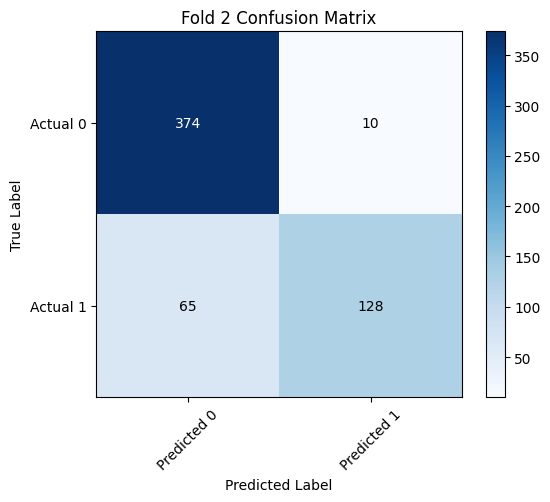

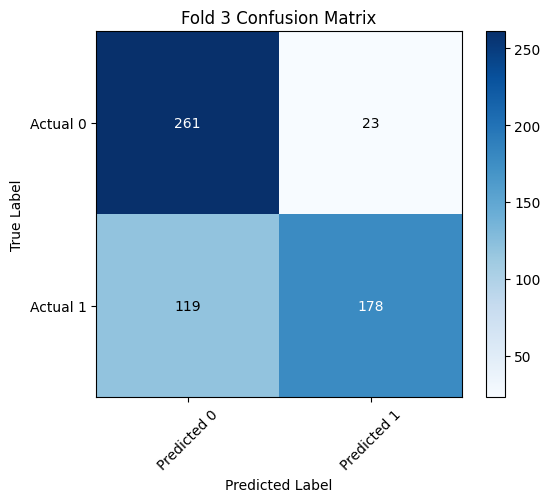

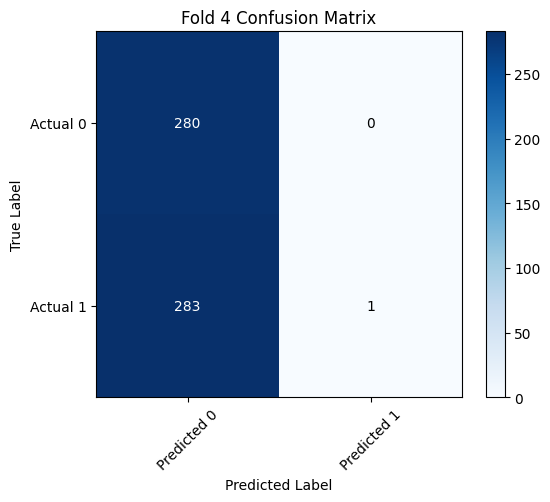

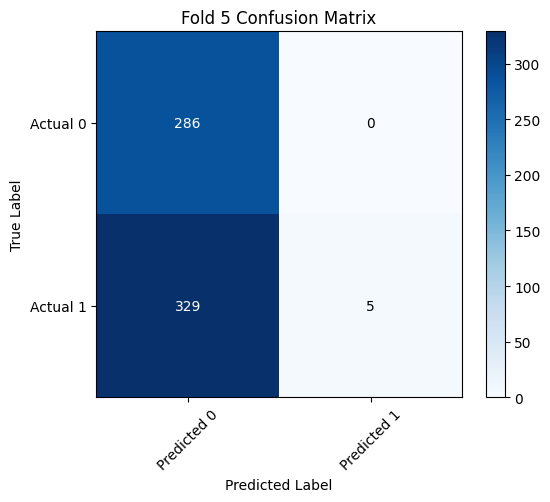


--- Average Confusion Matrix Across All Folds ---


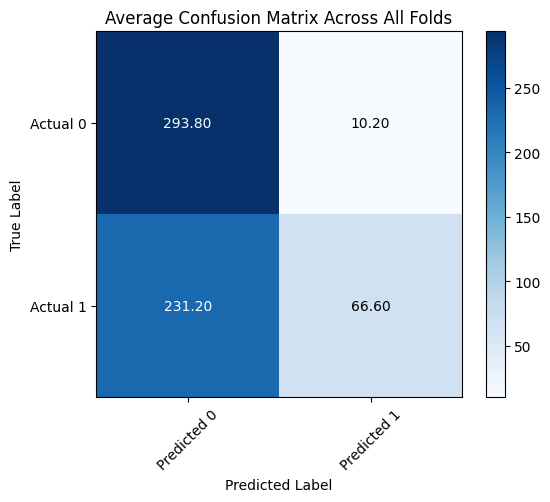

In [ ]:
# This section displays the individual confusion matrix for each cross-validation fold, as well as the average confusion matrix calculated across all folds.

import matplotlib.pyplot as plt
import numpy as np

# Assuming all_fold_confusion_matrices is available

print("--- Confusion Matrices Per Fold ---")

for fold_num, conf_matrix in enumerate(all_fold_confusion_matrices):
    plt.figure(figsize=(6, 5))
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f'Fold {fold_num + 1} Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Predicted 0', 'Predicted 1'], rotation=45)
    plt.yticks(tick_marks, ['Actual 0', 'Actual 1'])

    fmt = 'd' # For integer counts
    thresh = conf_matrix.max() / 2.
    for i in range(conf_matrix.shape[0]):
        for j in range(conf_matrix.shape[1]):
            plt.text(j, i, format(conf_matrix[i, j], fmt),
                     ha="center", va="center",
                     color="white" if conf_matrix[i, j] > thresh else "black")

    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

print("\n--- Average Confusion Matrix Across All Folds ---")
# The average confusion matrix was already computed in the CV cell, but re-plotting for consistency
# avg_conf_matrix variable should be available

avg_conf_matrix = np.mean(all_fold_confusion_matrices, axis=0)

plt.figure(figsize=(6, 5))
plt.imshow(avg_conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Average Confusion Matrix Across All Folds')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Predicted 0', 'Predicted 1'], rotation=45)
plt.yticks(tick_marks, ['Actual 0', 'Actual 1'])

fmt = '.2f' # For float values after averaging
thresh = avg_conf_matrix.max() / 2.
for i in range(avg_conf_matrix.shape[0]):
    for j in range(avg_conf_matrix.shape[1]):
        plt.text(j, i, format(avg_conf_matrix[i, j], fmt),
                 ha="center", va="center",
                 color="white" if avg_conf_matrix[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()